# Exploratory Data Analysis – E-commerce Customer Behavior
Understand customer purchasing behavior

Identify differences between active and churned customers

Derive business insights to justify churn & CLV modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/processed/cleaned_transactions.csv")

In [2]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
Revenue        float64
dtype: object

In [3]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#### Dataset Overview

In [5]:
df.shape

(406789, 9)

In [6]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [9]:
df['CustomerID'].nunique()

4371

In [10]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

> **Note: For revenue concentration and trend analysis, only positive-quantity transactions are considered to represent gross sales. Return behavior is analyzed separately in later sections.

In [11]:
# Filter to keep only positive quantities
df = df[df['Quantity'] > 0]

print(f"Minimum Quantity now: {df['Quantity'].min()}")
print(f"Maximum Quantity now: {df['Quantity'].max()}")

Minimum Quantity now: 1
Maximum Quantity now: 80995


In [12]:
# Keep only rows where UnitPrice is greater than 0
df = df[df['UnitPrice'] > 0]

print(f"Minimum Price now: {df['UnitPrice'].min()}")
print(f"Maximum Price now: {df['UnitPrice'].max()}")

Minimum Price now: 0.001
Maximum Price now: 8142.75


> Churn Definition (EDA):
A customer is labeled as churned if they have not made a purchase in the last 90 days of the dataset.

#### Customer-level metrics for EDA

In [27]:
customer_df = df.groupby('CustomerID').agg(
    last_purchase_date = ('InvoiceDate', 'max'),
    first_purchase_date = ('InvoiceDate', 'min'),
    frequency = ('InvoiceNo', 'nunique'),
    monetary = ('Revenue', 'sum'),
    avg_basket_value = ('Revenue', 'mean'),
    total_quantity = ('Quantity', 'sum'),
    return_quantity = ('Quantity', lambda x: x[x < 0].sum())
).reset_index()

# 2. Calculate Recency
today = df['InvoiceDate'].max() + pd.Timedelta(days=1)
customer_df['recency'] = (today - customer_df['last_purchase_date']).dt.days

# 3. Calculate Lifetime
customer_df['lifetime'] = (customer_df['last_purchase_date'] - customer_df['first_purchase_date']).dt.days

# 4. Calculate Velocity & Churn
customer_df['purchase_velocity'] = customer_df['frequency'] / (customer_df['lifetime'] + 1)
customer_df['is_churned'] = (customer_df['recency'] > 90).astype(int)

# 5. Calculate Return Ratio (handling potential zeros)
customer_df['return_ratio'] = (customer_df['return_quantity'].abs() / customer_df['total_quantity']).replace([np.inf, -np.inf], 0).fillna(0)

# Verify the columns are there
print("Columns in customer_df:", customer_df.columns.tolist())
customer_df.head()

Columns in customer_df: ['CustomerID', 'last_purchase_date', 'first_purchase_date', 'frequency', 'monetary', 'avg_basket_value', 'total_quantity', 'return_quantity', 'recency', 'lifetime', 'purchase_velocity', 'is_churned', 'return_ratio']


,CustomerID,last_purchase_date,first_purchase_date,frequency,monetary,avg_basket_value,total_quantity,return_quantity,recency,lifetime,purchase_velocity,is_churned,return_ratio
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,74215,0,326,0,1.000000,1,0.0
1,12347.0,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,23.681319,2458,0,2,365,0.019126,0,0.0
2,12348.0,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,57.975484,2341,0,75,282,0.014134,0,0.0
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,24.076027,631,0,19,0,1.000000,0,0.0
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,197,0,310,0,1.000000,1,0.0


In [28]:
customer_df['churn'] = (customer_df['recency'] > 90).astype(int)


In [29]:
# CREATING INVOICEMONTH
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

In [30]:
# --- METRICS ---
# Total Revenue using your existing column
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $8,911,407.90


In [31]:
# 2. Define the missing variables
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
monthly_revenue = df.groupby('InvoiceMonth')['Revenue'].sum()

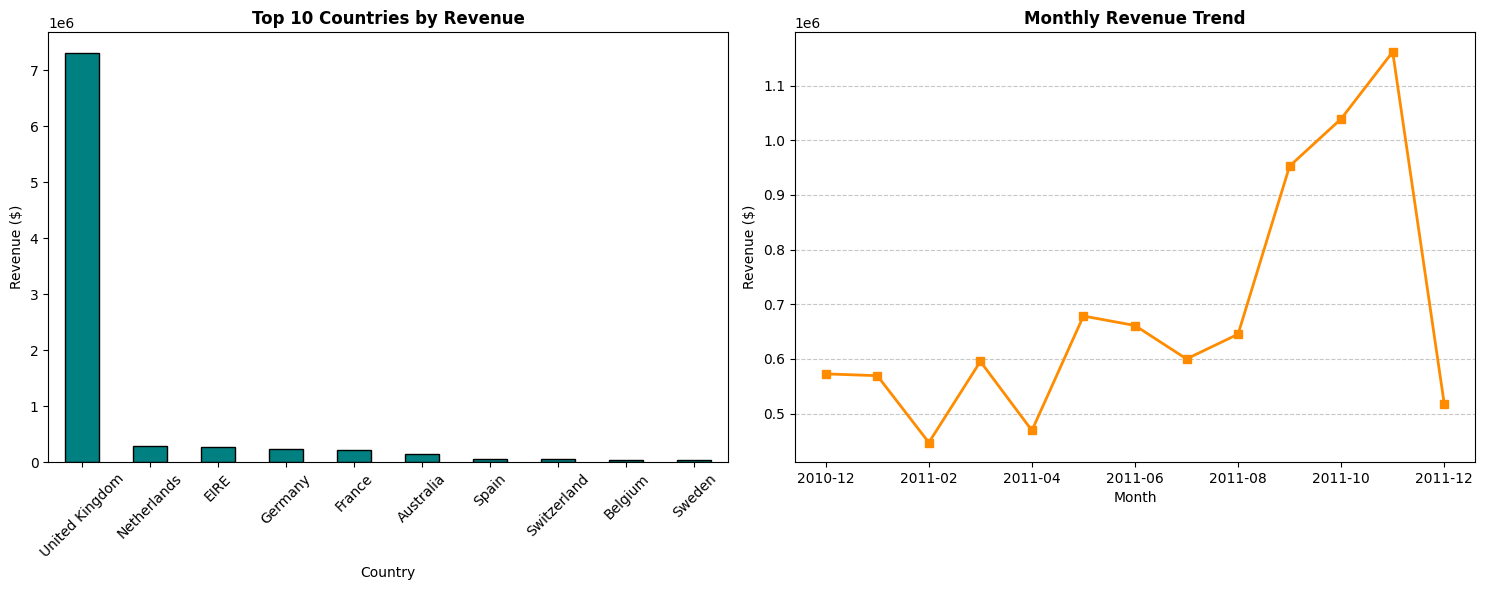

In [32]:
# Set up the plotting area
plt.figure(figsize=(15, 6))

# --- Chart 1: Bar Chart (Top 10 Countries) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
top_countries.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Countries by Revenue', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Country')
plt.xticks(rotation=45)

# --- Chart 2: Line Chart (Monthly Trend) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
monthly_revenue.plot(kind='line', marker='s', color='darkorange', linewidth=2)
plt.title('Monthly Revenue Trend', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

> **Revenue is heavily concentrated in the United Kingdom, which contributes the vast majority of total sales. International markets exist but operate at a significantly smaller scale, indicating a UK-centric customer base with limited global revenue diversification.**

---

> **Monthly revenue shows an upward trend toward the latter half of the year, suggesting increased purchasing activity, possibly driven by seasonal demand. The sharp decline in the final month aligns with dataset cutoff rather than a true demand drop.**


---


In [33]:
# 1. Calculate Revenue per Customer
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).reset_index()

In [24]:
# 2. Calculate Cumulative Contribution
# Calculate the running total of revenue
customer_revenue['CumRevenue'] = customer_revenue['Revenue'].cumsum()

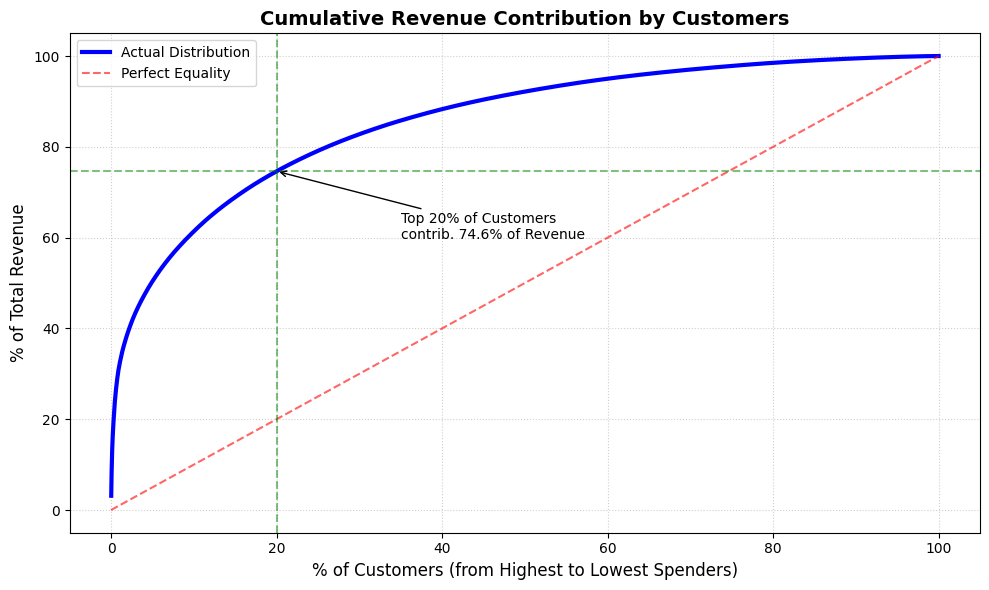

In [25]:
# Convert to percentages
total_rev = customer_revenue['Revenue'].sum()
total_cust = len(customer_revenue)

customer_revenue['CumPercentRevenue'] = (customer_revenue['CumRevenue'] / total_rev) * 100
customer_revenue['CumPercentCustomers'] = (np.arange(1, total_cust + 1) / total_cust) * 100

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# The Lorenz Curve
plt.plot(customer_revenue['CumPercentCustomers'], customer_revenue['CumPercentRevenue'], 
         label='Actual Distribution', color='blue', linewidth=3)

# The "Line of Equality" (if everyone spent exactly the same)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect Equality', alpha=0.6)

# Formatting the chart
plt.title('Cumulative Revenue Contribution by Customers', fontsize=14, fontweight='bold')
plt.xlabel('% of Customers (from Highest to Lowest Spenders)', fontsize=12)
plt.ylabel('% of Total Revenue', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: Add a marker for the 20% mark
top_20_val = customer_revenue.iloc[int(total_cust * 0.2)]['CumPercentRevenue']
plt.axvline(x=20, color='green', linestyle='--', alpha=0.5)
plt.axhline(y=top_20_val, color='green', linestyle='--', alpha=0.5)
plt.annotate(f'Top 20% of Customers\ncontrib. {top_20_val:.1f}% of Revenue', 
             xy=(20, top_20_val), xytext=(35, top_20_val-15),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.show()

> **Revenue contribution is highly skewed: the top 20% of customers account for approximately 75% of total revenue. This indicates strong dependence on a small high-value customer segment, making targeted retention and value-based segmentation critical for business sustainability.**


---


> **The dataset represents approximately $8.9M in gross retail revenue over a one-year period, providing sufficient scale for meaningful customer and revenue behavior analysis.**


---

## ✅ FINAL: CLEAN “REVENUE OVERVIEW” SECTION 


> **Revenue analysis reveals strong concentration patterns across both geography and customers. The United Kingdom dominates total sales, indicating a largely domestic customer base. Revenue contribution follows a highly skewed distribution, where approximately 20% of customers generate nearly 75% of total revenue. Monthly revenue trends show increased activity toward the latter part of the year, suggesting seasonal demand effects. These findings highlight the business’s reliance on a small group of high-value customers and justify further analysis into customer retention and lifetime value.**

---

C:\Users\GIFTY\AppData\Local\Temp\ipykernel_23192\208685379.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='frequency', data=customer_df, ax=axes[0,0], palette='Set2')
C:\Users\GIFTY\AppData\Local\Temp\ipykernel_23192\208685379.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monetary', data=customer_df, ax=axes[0,1], palette='Set2')
C:\Users\GIFTY\AppData\Local\Temp\ipykernel_23192\208685379.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='lifetime', data=customer_df, ax=axes[1,0], pale

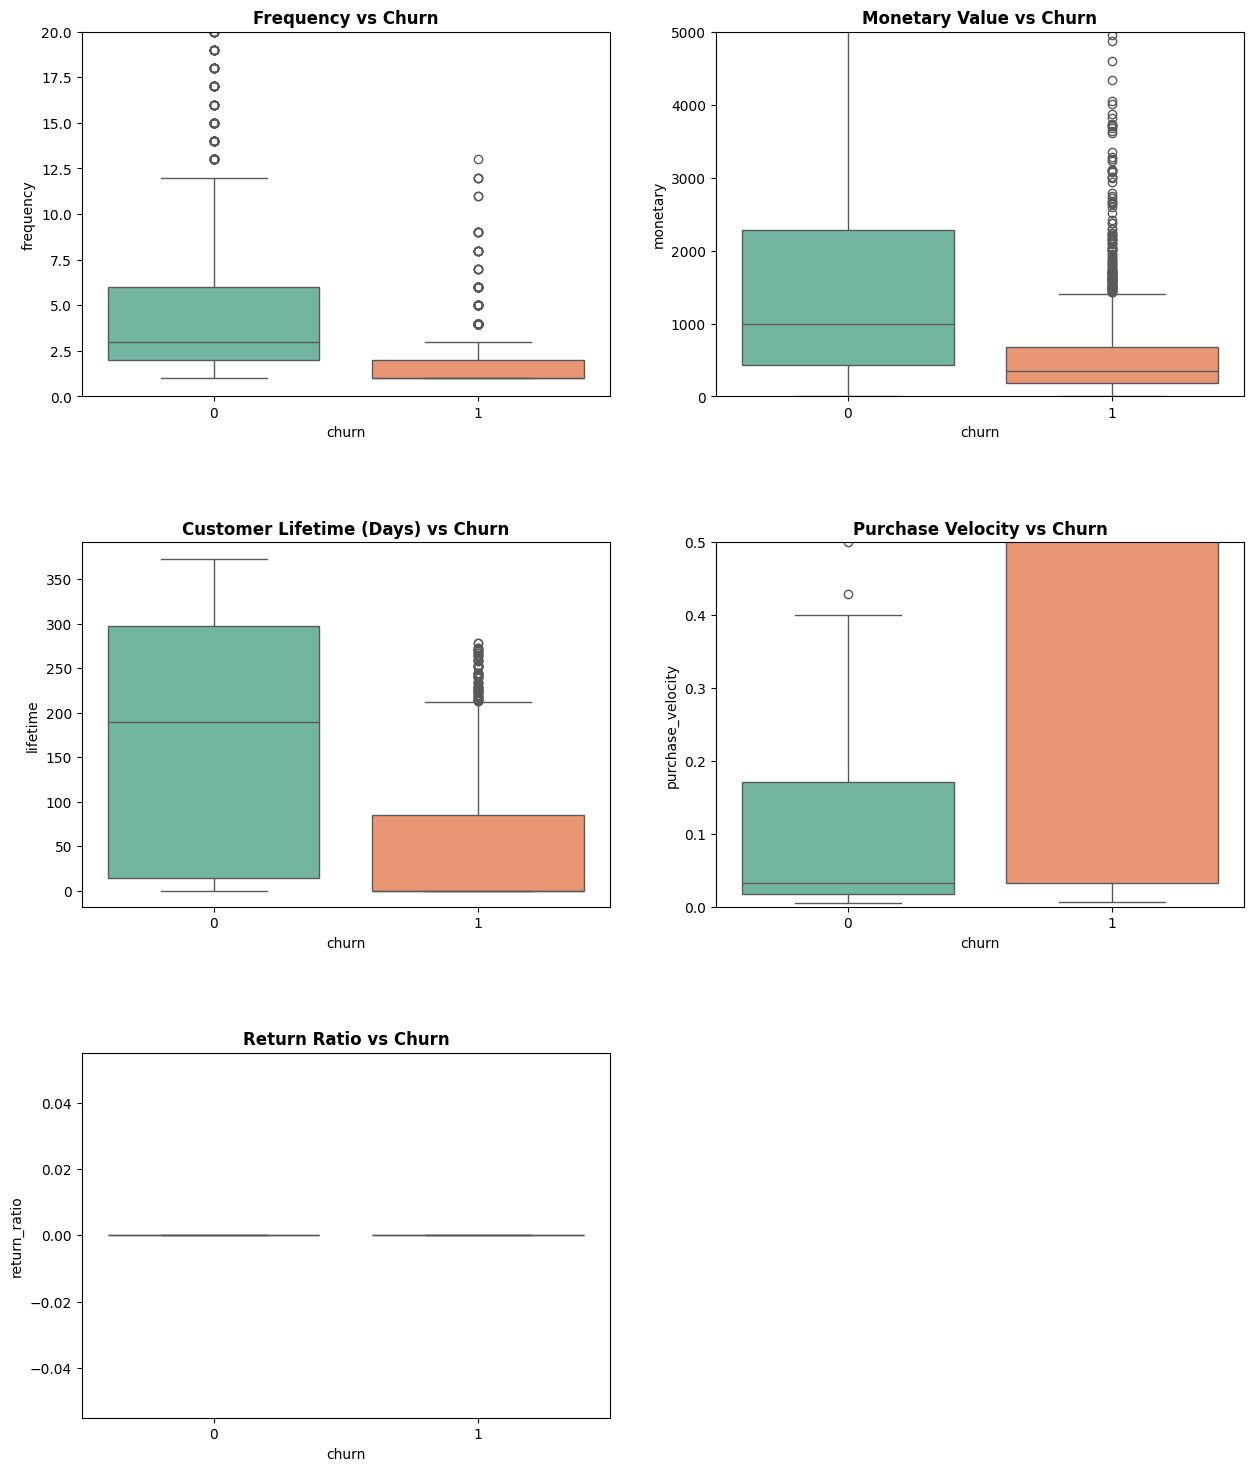

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if 'churn' exists; if you used 'is_churned' in the previous step, 
# let's make sure 'churn' is defined for the plot:
if 'churn' not in customer_df.columns and 'is_churned' in customer_df.columns:
    customer_df['churn'] = customer_df['is_churned']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4)

# Plot 1: frequency (Lowercase 'f')
sns.boxplot(x='churn', y='frequency', data=customer_df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Frequency vs Churn', fontweight='bold')
axes[0,0].set_ylim(0, 20) 

# Plot 2: monetary (Lowercase 'm')
sns.boxplot(x='churn', y='monetary', data=customer_df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Monetary Value vs Churn', fontweight='bold')
axes[0,1].set_ylim(0, 5000)

# Plot 3: lifetime (Lowercase 'l')
sns.boxplot(x='churn', y='lifetime', data=customer_df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Customer Lifetime (Days) vs Churn', fontweight='bold')

# Plot 4: purchase_velocity (Match your specific column name)
sns.boxplot(x='churn', y='purchase_velocity', data=customer_df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Purchase Velocity vs Churn', fontweight='bold')
axes[1,1].set_ylim(0, 0.5)

# Plot 5: return_ratio (Match your specific column name)
sns.boxplot(x='churn', y='return_ratio', data=customer_df, ax=axes[2,0], palette='Set2')
axes[2,0].set_title('Return Ratio vs Churn', fontweight='bold')

# Remove the empty 6th subplot
fig.delaxes(axes[2,1])

plt.show()